In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

# Import PyTorch
import torch

import numpy as np

# For plotting
\
%matplotlib inline
# also try %matplotlib widget

import matplotlib.pyplot as plt

# for performance measurements
import time


print(f"Default device is {sionna.phy.config.device}")

Default device is cuda:0


本次實驗目標為模擬基本的通訊架構，如下圖

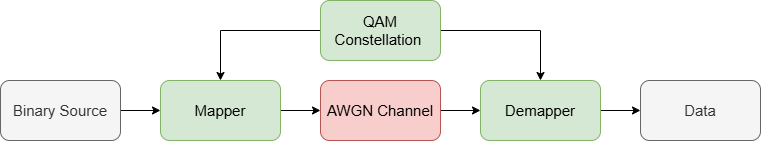

在基礎教學中將學習如何使用Sionna建立一個簡單的End-to-end通訊系統。從二進位的原始資料到訊號的Modulation、Channel、Demodulation，最後還原出二進位原始資料並計算其Bit error rate(BER)

In [2]:
#生成binary source
binary_source = sionna.phy.mapping.BinarySource()

#sionna支援batch的計算
batch_size=10
#設定資料長度
data_length=1024

data_bits = binary_source([batch_size, data_length])

print("Shape of data bits: ", data_bits.shape)
print("Raw data:")
print(data_bits)

Shape of data bits:  torch.Size([10, 1024])
Raw data:
tensor([[1., 0., 1.,  ..., 1., 1., 0.],
        [0., 1., 0.,  ..., 1., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 1., 1.],
        [1., 0., 1.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 1., 1., 1.]], device='cuda:0')


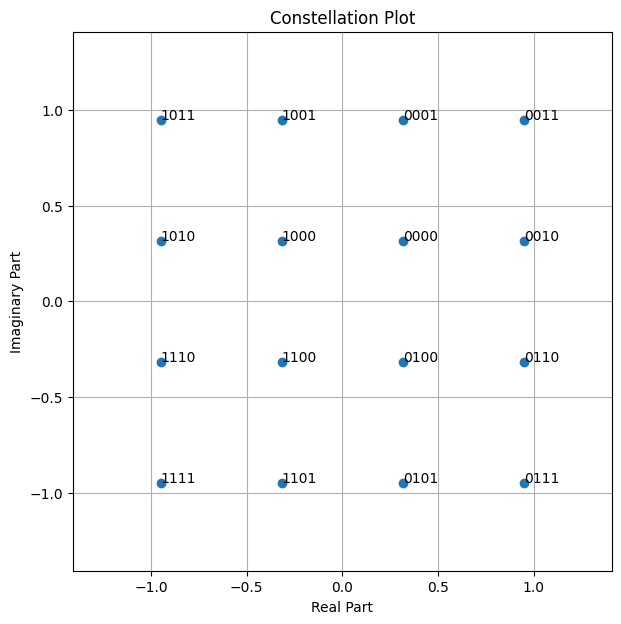

In [3]:
#生成mapper和demapper (modulation/demodulation)
num_bits_per_symbol =4  # 2 for QPSK, 4 for 16QAM

#定義星座圖與視覺化
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
constellation.show();

#使用相同的星座圖來定義mapper和demapper
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
demapper = sionna.phy.mapping.Demapper("app", constellation=constellation)

## Definition for the underlying function of 'ebnodb2no'

### The `sionna.phy.utils.ebnodb2no` function is a utility in the **Sionna** library used to compute the noise power spectral density $N_0$ (often denoted as `no`) required to achieve a specific $E_b/N_0$ (energy per information bit to noise power spectral density ratio) in decibels.

### Function Overview
In communication simulations, signal energy is typically normalized (e.g., $E_s = 1$). This function calculates the corresponding noise level $N_0$ by accounting for modulation order, code rate, and any overhead from the transmission grid.

---

### Parameters
| Parameter | Type | Description |
| :--- | :--- | :--- |
| `ebno_db` | `float` / `Tensor` | The desired $E_b/N_0$ value in dB. |
| `num_bits_per_symbol` | `int` / `float` | Number of bits per constellation symbol (e.g., 2 for QPSK, 4 for 16-QAM). |
| `coderate` | `float` | The rate of the Forward Error Correction (FEC) code. |
| `resource_grid` | `ResourceGrid` | *(Optional)* An instance of Sionna's `ResourceGrid`. If provided, it automatically accounts for pilot/guard overhead. |

---

### Mathematical Formula
The function internally implements the conversion from $E_b/N_0$ to $N_0$ using the following relationship:

1.  **Calculate $E_s/N_0$ (Linear):**
The relationship between the linear symbol-to-noise ratio ($E_s/N_0$) and the bit-to-noise ratio in decibels ($E_b/N_0)_{dB}$) is calculated as follows:

$$(E_s/N_0)_{linear} = 10^{\frac{(E_b/N_0)_{dB}}{10}} \cdot \text{num_bits_per_symbol} \cdot \text{coderate} \cdot \eta_{grid}$$

### Variable Definitions

| Variable | Description |
| :--- | :--- |
| **$(E_b/N_0)_{dB}$** | Energy per information bit to noise power spectral density ratio (in dB). |
| **$\text{num\_bits\_per\_symbol}$** | Modulation order (e.g., 2 for QPSK, 4 for 16-QAM, 6 for 64-QAM). |
| **$\text{coderate}$** | The rate of the Forward Error Correction (FEC) code. |
| **$\eta_{grid}$** | **Resource Grid Efficiency**: The ratio of data resource elements to total resource elements (accounts for pilots/guard bands). |

---

### Implementation Note
> If no `resource_grid` is provided in the configuration, the efficiency factor is assumed to be **$\eta_{grid} = 1$**.

2.  **Calculate $N_0$:**
    Assuming unit energy per symbol ($E_s = 1$):
    $$N_0 = \frac{1}{(E_s/N_0)_{linear}}$$

---

### Usage Example
https://nvlabs.github.io/sionna/phy/api/utils/sionna.phy.utils.ebnodb2no.html

In [4]:
#生成AWGN channel
awgn_channel = sionna.phy.channel.AWGN()

#當SNR_db為10的時候，可以透過ebnodb2no讓訊號SNR控制在10dB。ebno為「每bit的能量除以雜訊功率密度」，可以當作SNR的一種形式
SNR_db=10
no = sionna.phy.utils.ebnodb2no(ebno_db=SNR_db,
                        num_bits_per_symbol=num_bits_per_symbol,
                        coderate=1.0) # Coderate set to 1 as we do uncoded transmission here

add explanation on the data_length = need to be divisible by "num_bits_per_symbol"

In [5]:
#完整模擬流程
batch_size=10
data_length=1024  # block length
print("generate data ...")
data_bits = binary_source([batch_size, data_length])
print("Shape of data: ", data_bits.shape)

#把data_bits輸入到mapper轉換成x
x = mapper(data_bits)
print("Shape of x: ", x.shape)

#x經過channel後的訊號變成y
y = awgn_channel(x, no)
print("Shape of y: ", y.shape)

#在接收端讓訊號y經過demapper計算後取得LLR(log-likelihood ratio)
llr = demapper(y, no)
print("Shape of llr: ", llr.shape)

# 將LLR轉換為bits (0 或 1)
data_bits_received = sionna.phy.utils.hard_decisions(llr)
print("Shape of received data", data_bits_received.shape)

ber=sionna.phy.utils.compute_ber(data_bits, data_bits_received)
print(f"BER: {ber}" )

generate data ...
Shape of data:  torch.Size([10, 1024])
Shape of x:  torch.Size([10, 256])
Shape of y:  torch.Size([10, 256])
Shape of llr:  torch.Size([10, 1024])
Shape of received data torch.Size([10, 1024])
BER: 0.0018554687500000001


how to plot the demapped llr --> 3D

In [6]:
#各個參數的詳細資訊
import numpy as np
num_samples = 8 # how many samples shall be printed
num_symbols = int(num_samples/num_bits_per_symbol)

print(f"First {num_samples} transmitted bits: {data_bits[0,:num_samples]}")
print(f"First {num_symbols} transmitted symbols: {np.round(x.cpu()[0,:num_symbols], 2)}")
print(f"First {num_symbols} received symbols: {np.round(y.cpu()[0,:num_symbols], 2)}")
print(f"First {num_samples} demapped llrs: {np.round(llr.cpu()[0,:num_samples], 2)}")
print(f"First {num_samples} demapped received data: {np.round(data_bits_received.cpu()[0,:num_samples], 2)}")


First 8 transmitted bits: tensor([0., 1., 0., 1., 0., 1., 0., 1.], device='cuda:0')
First 2 transmitted symbols: tensor([0.3200-0.9500j, 0.3200-0.9500j])
First 2 received symbols: tensor([0.2100-1.0400j, 0.2800-0.9700j])
First 8 demapped llrs: tensor([-10.5100,  73.6500, -21.4900,  20.8200, -14.3800,  66.1900, -17.6200,
         17.1000])
First 8 demapped received data: tensor([0., 1., 0., 1., 0., 1., 0., 1.])


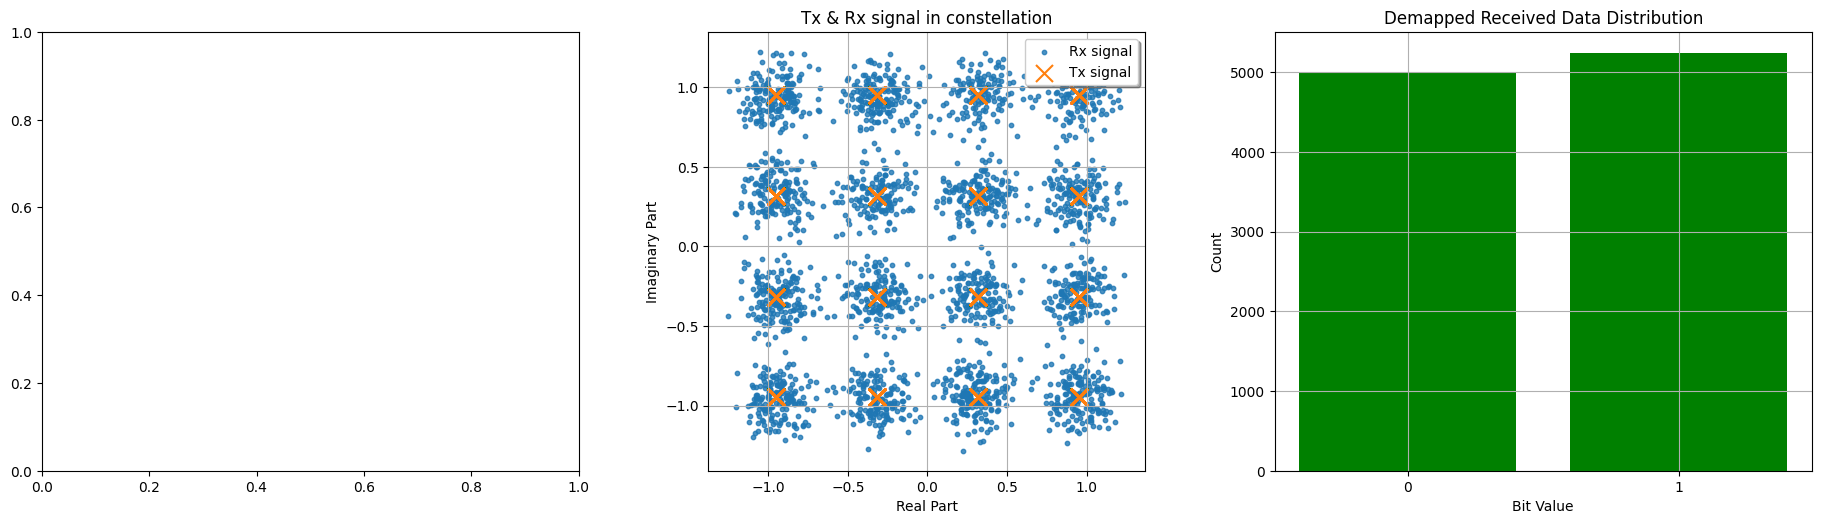

In [15]:
# Plot 1: Transmitted and Received Symbols (Constellation Diagram)
plt.figure(figsize=(18, 6)) # Adjust figure size for multiple subplots

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
plt.axes().set_aspect(1)
plt.grid(True)
plt.title('Tx & Rx signal in constellation')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
# Ensure data is on CPU and converted to numpy for plotting
plt.scatter(y.cpu().real.flatten().numpy(), y.cpu().imag.flatten().numpy(), label="Rx signal", alpha=0.8, s=10) # Increased alpha and s for better visibility
plt.scatter(x.cpu().real.flatten().numpy(), x.cpu().imag.flatten().numpy(), label="Tx signal", marker='x', s=150) # Increased marker size
plt.legend(loc='upper right', shadow=True)


# Plot 3: Demapped Received Data (Hard Decisions)
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
plt.title('Demapped Received Data Distribution')
plt.xlabel('Bit Value')
plt.ylabel('Count')
data_bits_received_np = data_bits_received.cpu().flatten().numpy()
plt.hist(data_bits_received_np, bins=[-0.5, 0.5, 1.5], rwidth=0.8, align='mid', color='green')
plt.xticks([0, 1])
plt.grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

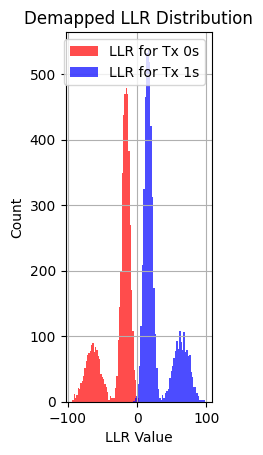

In [12]:
# Plot 2: Demapped LLR Distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
plt.title('Demapped LLR Distribution')
plt.xlabel('LLR Value')
plt.ylabel('Count')
# Separate LLRs based on original transmitted bits
llr_np = llr.cpu().flatten().numpy()
data_bits_np = data_bits.cpu().flatten().numpy()

llr_zeros = llr_np[data_bits_np == 0]
llr_ones = llr_np[data_bits_np == 1] # Corrected typo here from ll_np to llr_np

plt.hist(llr_zeros, bins=50, alpha=0.7, label='LLR for Tx 0s', color='red')
plt.hist(llr_ones, bins=50, alpha=0.7, label='LLR for Tx 1s', color='blue')
plt.legend(loc='best') # Changed legend location to 'best' to avoid overlap
plt.grid(True)


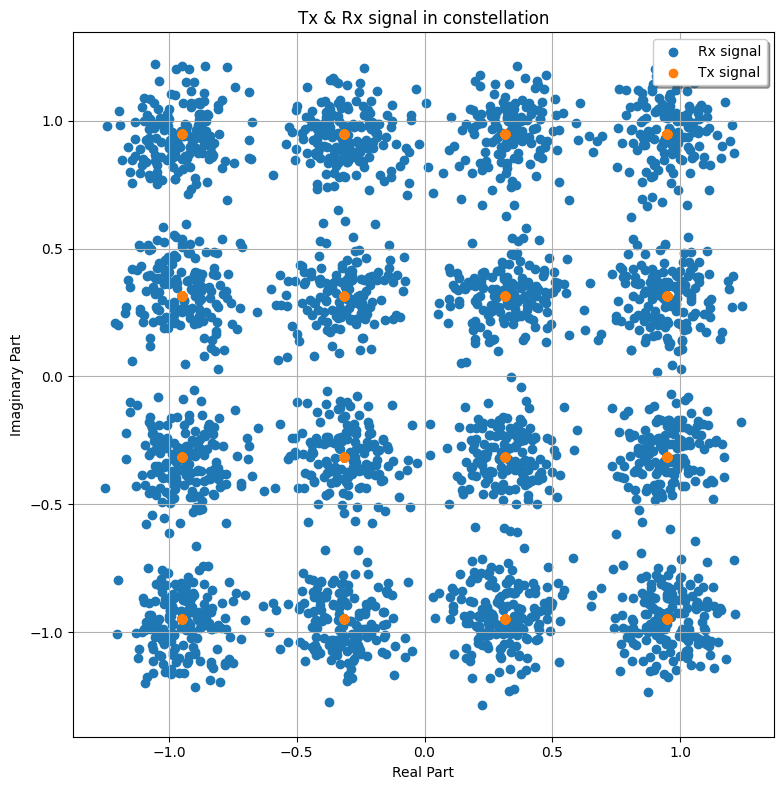

In [16]:
#圖像化收到的訊號(訊號經過Channel後的輸出)


plt.figure(figsize=(8,8))
plt.axes().set_aspect(1)
plt.grid(True)
plt.title('Tx & Rx signal in constellation')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.scatter(y.cpu().real.flatten().numpy(), y.cpu().imag.flatten().numpy(), label="Rx signal") #Rx訊號分布
plt.scatter(x.cpu().real.flatten().numpy(), x.cpu().imag.flatten().numpy(), label="Tx signal") #Tx訊號分布
plt.legend(loc='upper right', shadow=True)
plt.tight_layout()

## 將各個Block的功能組合成一個通訊系統
如下圖，我們可以在Sionna裡面把這些模組化的功能組合成一個通訊系統，將所有功能打包並簡化成單純的「Input->系統->Output」，變成一個**End-to-end model**，方便未來部署以及系統效能驗證


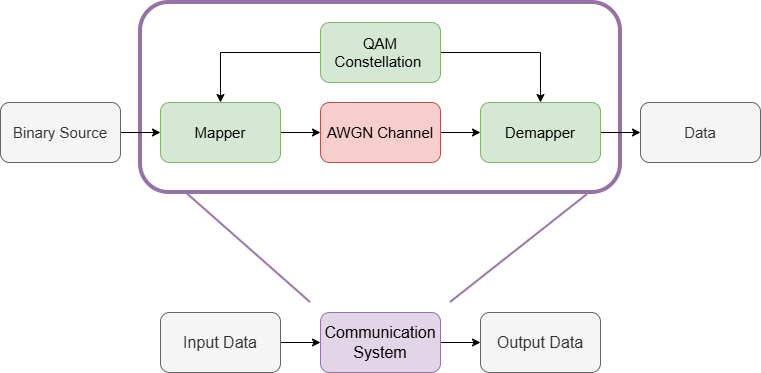



In [17]:
#sionna.phy的所有模組都繼承了Block
#在這個部分我們將會自訂一個Block，並把所有功能都串在一起

class UncodedSystemAWGN(sionna.phy.Block):
    def __init__(self, num_bits_per_symbol, block_length):
        """
        A Sionna Block for uncoded transmission over the AWGN channel

        Parameters
        ----------
        num_bits_per_symbol: int
            The number of bits per constellation symbol, e.g., 4 for QAM16.

        block_length: int
            The number of bits per transmitted message block (will be the codeword length later).

        Input
        -----
        batch_size: int
            The batch_size of the Monte-Carlo simulation.

        ebno_db: float
            The `Eb/No` value (=rate-adjusted SNR) in dB.

        Output
        ------
        (bits, bits_hat):
            Tuple:

        bits: torch.Tensor
            A tensor of shape `[batch_size, block_length] of 0s and 1s
            containing the transmitted information bits.

        bits_hat: torch.Tensor
            A tensor of shape `[batch_size, block_length] containing the
            received log-likelihood-ratio (LLR) with hard_decisions values.
        """

        super().__init__() # Must call the block initializer

        self.num_bits_per_symbol = num_bits_per_symbol
        self.block_length = block_length
        self.constellation = sionna.phy.mapping.Constellation("qam", self.num_bits_per_symbol)
        self.mapper = sionna.phy.mapping.Mapper(constellation=self.constellation)
        self.demapper = sionna.phy.mapping.Demapper("app", constellation=self.constellation)
        self.binary_source = sionna.phy.mapping.BinarySource()
        self.awgn_channel = sionna.phy.channel.AWGN()

    # @torch.compile # Enable compilation to speed things up
    def call(self, batch_size, ebno_db):

        # no channel coding used; we set coderate=1.0
        no = sionna.phy.utils.ebnodb2no(ebno_db,
                                num_bits_per_symbol=self.num_bits_per_symbol,
                                coderate=1.0)

        bits = self.binary_source([batch_size, self.block_length]) # Blocklength set to 1024 bits
        x = self.mapper(bits)
        y = self.awgn_channel(x, no)
        llr = self.demapper(y,no)
        bits_hat = sionna.phy.utils.hard_decisions(llr)
        return bits, bits_hat

In [18]:
#初始化通訊系統
NUM_BITS_PER_SYMBOL=2
BLOCK_LENGTH=1024
uncoded_awgn_sys = UncodedSystemAWGN(num_bits_per_symbol=NUM_BITS_PER_SYMBOL, block_length=BLOCK_LENGTH)

In [19]:
#通訊系統BER測試

BATCH_SIZE=10
EBNO_DB_LIST=[0, 5, 10]

for EBNO_DB in EBNO_DB_LIST:
    #執行uncoded_awgn_sys()，input資料是BATCH_SIZE和EBNO_DB，Output是bits, bits_hat
    bits, bits_hat=uncoded_awgn_sys(batch_size=BATCH_SIZE, ebno_db=EBNO_DB)
    #計算BER
    ber=sionna.phy.utils.compute_ber(bits, bits_hat)
    print(f"SNR: {EBNO_DB}, BER: {ber:4f}" )

SNR: 0, BER: 0.078809
SNR: 5, BER: 0.004883
SNR: 10, BER: 0.000000
